# Prediction for BioDiversity

## 1. Preparation

### Imports

In [12]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [3]:
pip install --upgrade scikit-learn==1.5.1 joblib==1.4.2

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for scikit-learn==1.5.1 from https://files.pythonhosted.org/packages/32/63/ed228892adad313aab0d0f9261241e7bf1efe36730a2788ad424bcad00ca/scikit_learn-1.5.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
  Using cached scikit_learn-1.5.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (12 kB)
  Obtaining dependency information for joblib==1.4.2 from https://files.pythonhosted.org/packages/91/29/df4b9b42f2be0b623cbd5e2140cafcaa2bef0759a00b7b70104dcfe2fb51/joblib-1.4.2-py3-none-any.whl.metadata
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
Using cached scikit_learn-1.5.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.3 MB)
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)

[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you ma

### Uploading file

In [4]:
df = pd.read_csv('./data/Ocean_Health_Index_2018_global_scores.csv')

In [5]:
df.head().T

,0,1,2,3,4
OBJECTID,1,2,3,4,5
rgn_typ,eez,eez,eez,eez,eez
rgn_id,1,10,100,101,102
rgn_nam,Cocos Islands,Nauru,Republique du Congo,Namibia,South Africa
rgn_key,CCK,NRU,COG,NAM,ZAF
are_km2,470116.600596,310565.147207,39863.596821,562727.622426,1069377.88035
AO,96.97,59.2,53.71,88.4,77.5
BD,90.28,82.94,87.2,90.33,88.04
CP,97.62,97.09,0.0,0.0,99.63
CS,92.76,0.0,0.0,0.0,99.82


## 2. Visualization

In [6]:
display(df.describe())

,OBJECTID,rgn_id,are_km2,AO,BD,CP,CS,CW,ECO,FIS,...,LIV,LSP,MAR,NP,SP,SPP,TR,trnd_sc,Shape__Area,Shape__Length
count,219.000000,219.000000,2.190000e+02,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,...,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,2.190000e+02,2.190000e+02
mean,111.447489,116.493151,6.369748e+05,75.539863,85.929041,62.878447,53.789178,62.391050,79.625708,46.465571,...,72.622420,54.593927,10.061689,22.611142,60.518128,82.249772,46.244338,-0.095890,1.978184e+12,9.149822e+06
std,64.632204,68.297472,1.238609e+06,17.328091,6.328843,38.653589,40.743961,18.698405,30.403956,17.573461,...,29.114189,39.850326,22.621726,29.275119,21.168079,5.650156,34.950833,0.756381,9.391176e+12,3.096094e+07
min,1.000000,1.000000,1.863138e+02,42.660000,56.940000,0.000000,0.000000,15.080000,0.000000,10.160000,...,0.000000,0.000000,0.000000,0.000000,22.350000,63.030000,0.000000,-3.050000,2.470905e+08,7.336671e+04
25%,55.500000,58.500000,6.179355e+04,59.755000,82.765000,30.115000,0.000000,50.105000,71.650000,34.505000,...,59.360000,11.780000,0.000000,0.000000,39.500000,78.315000,14.245000,-0.455000,9.629957e+10,1.532736e+06
50%,111.000000,115.000000,2.520243e+05,77.950000,87.700000,81.300000,68.680000,61.270000,96.380000,46.170000,...,80.740000,59.930000,0.000000,3.740000,62.370000,83.000000,44.060000,-0.010000,3.033444e+11,2.811692e+06
75%,167.500000,174.500000,5.707822e+05,90.890000,90.000000,94.695000,90.630000,74.545000,100.000000,56.645000,...,99.575000,100.000000,6.595000,42.790000,81.535000,86.125000,78.825000,0.360000,7.820829e+11,5.744138e+06
max,222.000000,250.000000,8.591244e+06,100.000000,97.070000,100.000000,100.000000,99.710000,100.000000,94.200000,...,100.000000,100.000000,100.000000,99.980000,97.730000,94.700000,100.000000,2.330000,1.022129e+14,3.315996e+08


In [7]:
df = df.drop(columns=['rgn_typ', 'rgn_nam', 'rgn_key'])

### Visualisatie van de correlatie tussen Carbon Storage en de andere variabelen.

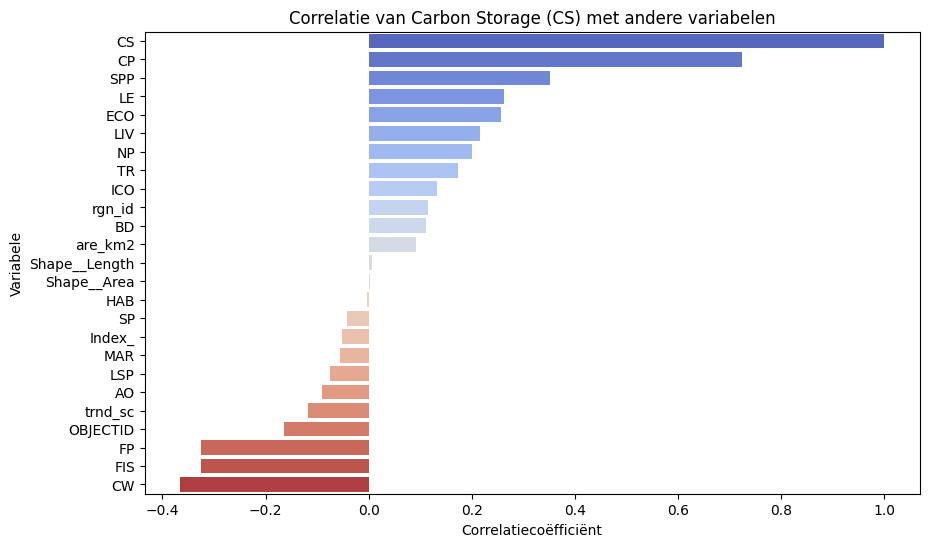

In [8]:
plt.figure(figsize=(10,6))
corr = df.corr()['CS'].sort_values(ascending=False)
sns.barplot(x=corr, y=corr.index, palette='coolwarm')
plt.title('Correlatie van Carbon Storage (CS) met andere variabelen')
plt.xlabel('Correlatiecoëfficiënt')
plt.ylabel('Variabele')
plt.show()

In [9]:
print("Top 10 correlaties met CS:")
print(corr.head(10))

Top 10 correlaties met CS:
CS        1.000000
CP        0.723664
SPP       0.350990
LE        0.263303
ECO       0.255966
LIV       0.215897
NP        0.199381
TR        0.174145
ICO       0.133326
rgn_id    0.114915
Name: CS, dtype: float64


* Carbon Storage hangt sterk samen met Coastal Protection → ecologisch logische link.
* Economische en sociale stabiliteit (ECO, LE, LIV) dragen ook positief bij.
* Exploitatie-indicatoren (FIS, FP) hebben negatieve correlaties → menselijke druk verlaagt opslag.

In [10]:
(df == 0).sum()

OBJECTID           0
rgn_id             0
are_km2            0
AO                 0
BD                 0
CP                51
CS                70
CW                 0
ECO               16
FIS                0
FP                 1
HAB                1
ICO                0
Index_             0
LE                16
LIV               16
LSP               25
MAR              113
NP                96
SP                 0
SPP                0
TR                28
trnd_sc            0
Shape__Area        0
Shape__Length      0
dtype: int64

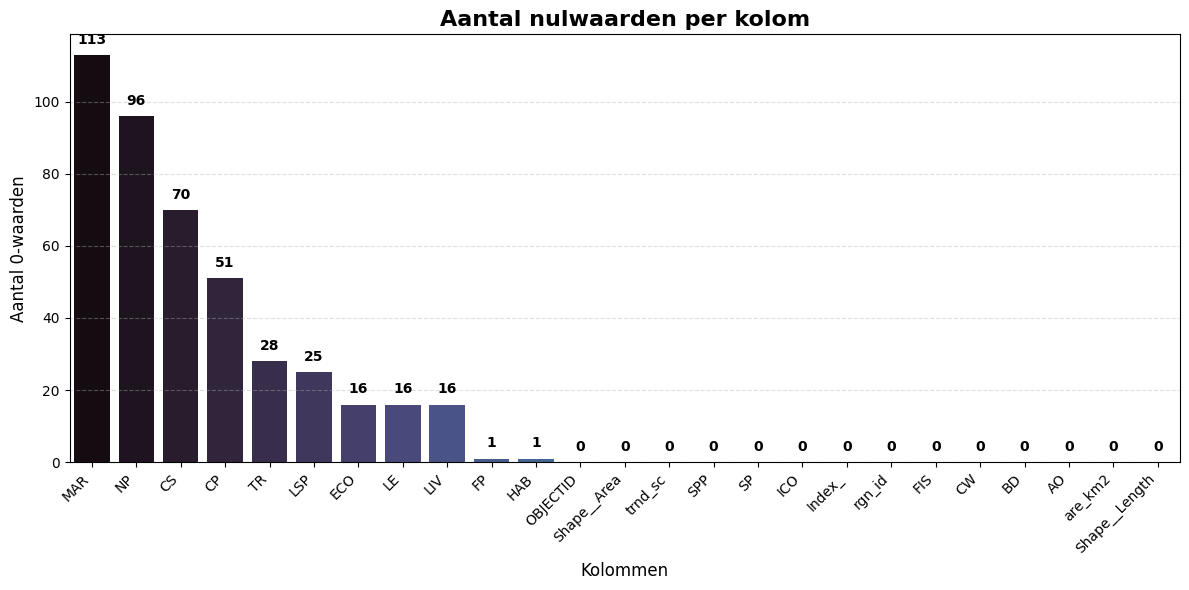

In [11]:
# Aantal nulwaarden per kolom
zeros_per_col = (df == 0).sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=zeros_per_col.index, y=zeros_per_col.values, palette="mako")

# Annotaties (aantal boven balken)
for i, v in enumerate(zeros_per_col.values):
    plt.text(i, v + (max(zeros_per_col.values)*0.02),  # iets hoger dan de top van de balk
             f"{v}", 
             ha='center', va='bottom', 
             fontweight='bold', fontsize=10, color='black')  # zwart goed zichtbaar

# Labels en stijlen
plt.title("Aantal nulwaarden per kolom", fontsize=16, fontweight="bold")
plt.xlabel("Kolommen", fontsize=12)
plt.ylabel("Aantal 0-waarden", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Visualisatie van de correlatie tussen Biodiversity en de andere variabelen.

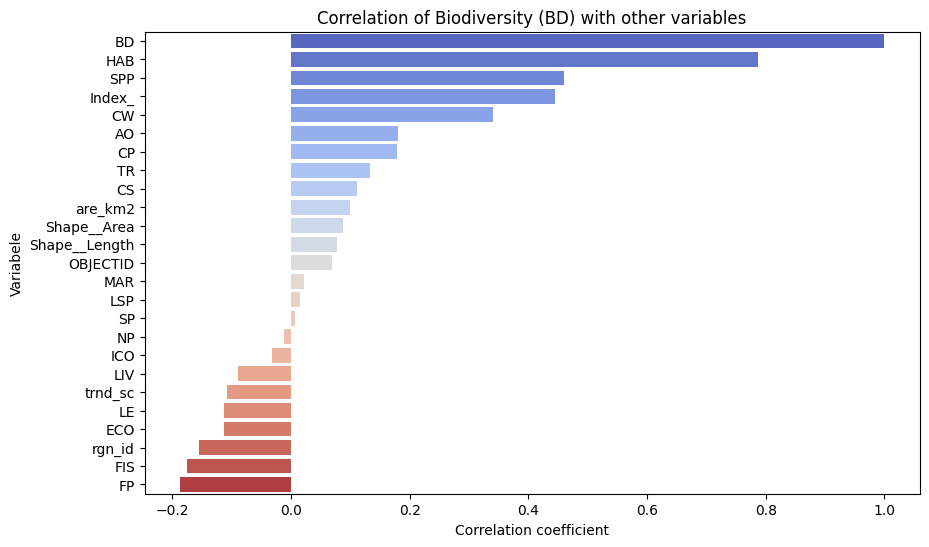

In [10]:
corr_bd = df.corr()['BD'].sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=corr_bd, y=corr_bd.index, palette='coolwarm')
plt.title('Correlation of Biodiversity (BD) with other variables')
plt.xlabel('Correlation coefficient')
plt.ylabel('Variabele')
plt.show()

In [11]:
print("Top 10 correlaties met BD:")
print(corr_bd.head(10))

Top 10 correlaties met BD:
BD         1.000000
HAB        0.786833
SPP        0.460222
Index_     0.444127
CW         0.341193
AO         0.180686
CP         0.178614
TR         0.133621
CS         0.111556
are_km2    0.099318
Name: BD, dtype: float64


Er is een trade-off tussen menselijke activiteit en ecologische kwaliteit — klassieke ecologische patroon: hoe meer exploitatie, hoe lager de biodiversiteit.

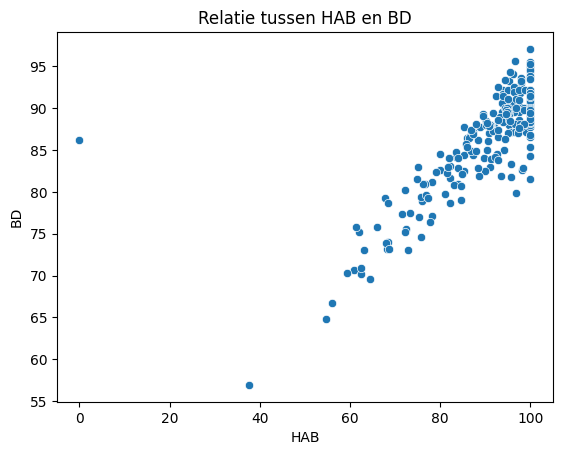

In [13]:
sns.scatterplot(x=df["HAB"], y=df["BD"])
plt.title("Relatie tussen HAB en BD")
plt.show()

## 3. Model training

In [15]:
X = df[['AO','CP','CS','CW','ECO','FIS','FP','HAB','ICO','Index_',
               'LE','LIV','LSP','MAR','NP','SP','SPP','TR','trnd_sc']]
y = df['BD']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
model_bd = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    max_depth=None,
    min_samples_leaf=2
)
model_bd.fit(X_train, y_train)

RandomForestRegressor(min_samples_leaf=2, n_estimators=500, random_state=42)

In [18]:
preds = model_bd.predict(X_test)

r2 = r2_score(y_test, preds)
mae = mean_absolute_error(y_test, preds)

print(f"✅ BD-model getraind!")
print(f"R²-score: {r2:.3f}")
print(f"Mean Absolute Error: {mae:.3f}")

✅ BD-model getraind!
R²-score: 0.959
Mean Absolute Error: 0.940


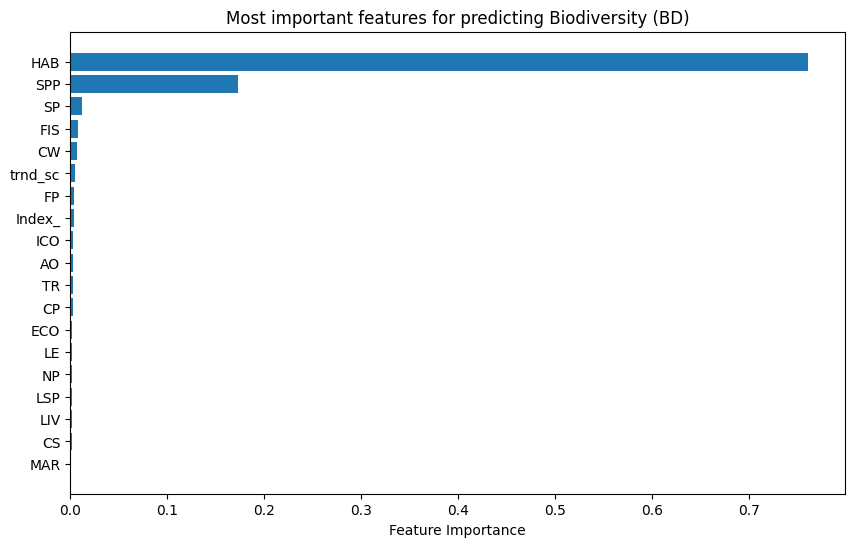

In [19]:
importance = model_bd.feature_importances_
indices = np.argsort(importance)[::-1]

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importance[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.gca().invert_yaxis()
plt.title("Most important features for predicting Biodiversity (BD)")
plt.xlabel("Feature Importance")
plt.show()


In [21]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model_bd.feature_importances_
}).sort_values('importance', ascending=False)

display(importance_df)

,feature,importance
7,HAB,0.760505
16,SPP,0.172854
15,SP,0.012382
5,FIS,0.008237
3,CW,0.006636
18,trnd_sc,0.005277
6,FP,0.004492
9,Index_,0.004211
8,ICO,0.003429
0,AO,0.003316


In [22]:
X_reduced = X[['HAB', 'SPP', 'CS', 'CP', 'CW']]

X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

model_bd_small = RandomForestRegressor(n_estimators=300, random_state=42)
model_bd_small.fit(X_train, y_train)

preds_small = model_bd_small.predict(X_test)
print(f"R²-score: {r2_score(y_test, preds_small):.3f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, preds_small):.3f}")

R²-score: 0.985
Mean Absolute Error: 0.557


In [23]:
r2_train = model_bd_small.score(X_train, y_train)
r2_test = model_bd_small.score(X_test, y_test)
print(f"R² train: {r2_train:.3f}")
print(f"R² test: {r2_test:.3f}")

R² train: 0.979
R² test: 0.985


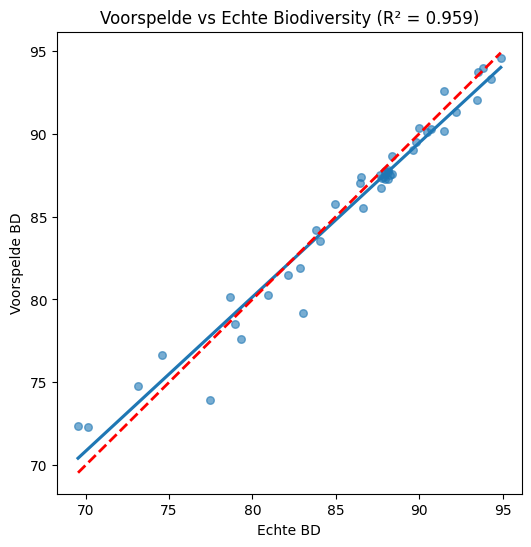

In [24]:
plt.figure(figsize=(6,6))
sns.regplot(x=y_test, y=preds, ci=None, scatter_kws={"s":30, "alpha":0.6})
plt.xlabel("Echte BD")
plt.ylabel("Voorspelde BD")
plt.title(f"Voorspelde vs Echte Biodiversity (R² = {r2_score(y_test, preds):.3f})")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)
plt.show()

### '0' waarden opvullen

In [23]:
df_filled = df.copy()

for col in X_reduced:
    print(f"\n==> Bezig met invullen van kolom: {col}")
    
    train_df = df_filled[df_filled[col] != 0]
    predict_df = df_filled[df_filled[col] == 0]
    
    if predict_df.empty:
        continue

    X_train = train_df.drop(columns=[col])
    y_train = train_df[col]
    X_pred = predict_df.drop(columns=[col])

    # Alleen numerieke kolommen
    X_train = X_train.select_dtypes(include=np.number)
    X_pred = X_pred.select_dtypes(include=np.number)

    # Model trainen
    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)

    # Waarden voorspellen
    df_filled.loc[df_filled[col] == 0, col] = model.predict(X_pred)

print("\n✅ Alle gekozen kolommen zijn ingevuld met voorspelde waarden.")


==> Bezig met invullen van kolom: HAB

==> Bezig met invullen van kolom: SPP

==> Bezig met invullen van kolom: CS

==> Bezig met invullen van kolom: CP

==> Bezig met invullen van kolom: CW

✅ Alle gekozen kolommen zijn ingevuld met voorspelde waarden.


In [24]:
X_reduced = X[['HAB', 'SPP', 'CS', 'CP', 'CW']]

X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

model_bd_small = RandomForestRegressor(n_estimators=300, random_state=42)
model_bd_small.fit(X_train, y_train)

preds_small = model_bd_small.predict(X_test)
print(f"R²-score: {r2_score(y_test, preds_small):.3f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, preds_small):.3f}")

R²-score: 0.985
Mean Absolute Error: 0.557


In [25]:
r2_train = model_bd_small.score(X_train, y_train)
r2_test = model_bd_small.score(X_test, y_test)
print(f"R² train: {r2_train:.3f}")
print(f"R² test: {r2_test:.3f}")


R² train: 0.979
R² test: 0.985


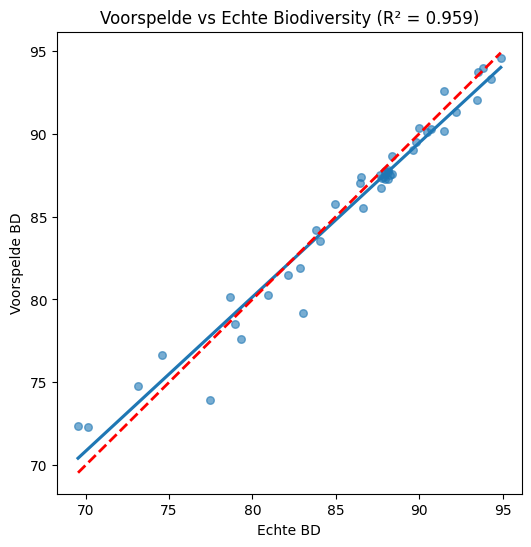

In [26]:
plt.figure(figsize=(6,6))
sns.regplot(x=y_test, y=preds, ci=None, scatter_kws={"s":30, "alpha":0.6})
plt.xlabel("Echte BD")
plt.ylabel("Voorspelde BD")
plt.title(f"Voorspelde vs Echte Biodiversity (R² = {r2_score(y_test, preds):.3f})")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)
plt.show()

### Predicted vs Actual plot

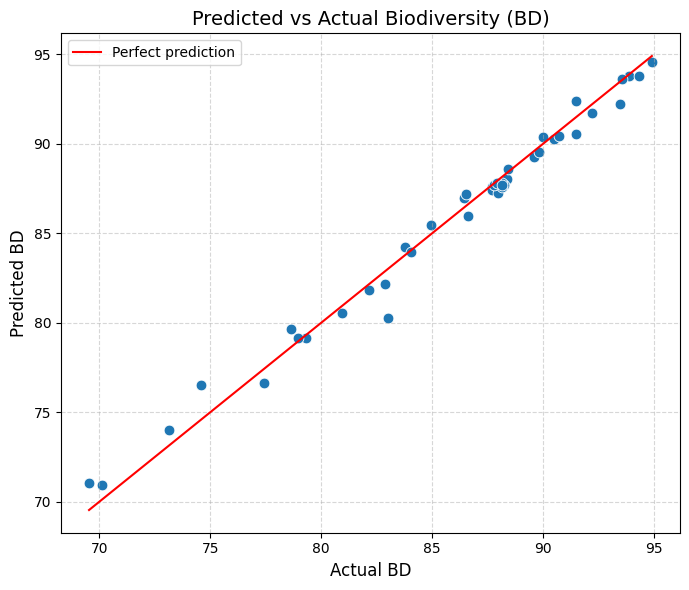

In [29]:
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test, y=preds_small, s=60)
sns.lineplot(x=y_test, y=y_test, color="red", label="Perfect prediction")

plt.title("Predicted vs Actual Biodiversity (BD)", fontsize=14)
plt.xlabel("Actual BD", fontsize=12)
plt.ylabel("Predicted BD", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Error distribution

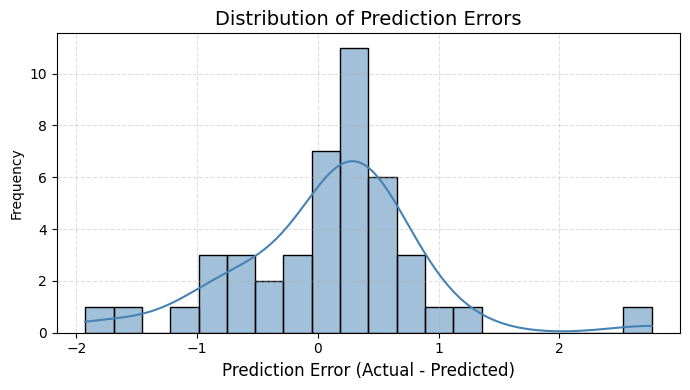

In [30]:
errors = y_test - preds_small

plt.figure(figsize=(7,4))
sns.histplot(errors, bins=20, kde=True, color="steelblue")
plt.title("Distribution of Prediction Errors", fontsize=14)
plt.xlabel("Prediction Error (Actual - Predicted)", fontsize=12)
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

De balken gecentreerd rond 0 → de meeste voorspellingen liggen dicht bij de echte waarden.

De lijn symmetrisch rond 0 → fouten zijn netjes verdeeld (geen structurele bias).

De breedte van de verdeling (~-2 tot +2) → voorspelfouten zijn maximaal 2 BD-punten.

### Feature importance

In [27]:
joblib.dump(model_bd_small, "biodiversity_model.pkl")
print("✅ Model opgeslagen als 'biodiversity_model.pkl'")

✅ Model opgeslagen als 'biodiversity_model.pkl'
